#Assignment 1.1

**Agentic AI**  
**Syed Ukkashah** 
**23K-0055** 

This notebook implements and compares **Bag of Words, TF-IDF, Word2Vec (Skip-gram), and BERT**. The same small corpus is used for all four methods so their vector sizes, sparsity, and cosine similarities can be compared fairly.

## 1. Setup

This cell installs only missing packages. The first BERT run also downloads `bert-base-uncased`.

In [1]:
import importlib.util, subprocess, sys

requirements = {
    'numpy': 'numpy', 'pandas': 'pandas', 'sklearn': 'scikit-learn',
    'gensim': 'gensim', 'torch': 'torch', 'transformers': 'transformers',
    'matplotlib': 'matplotlib', 'seaborn': 'seaborn'
}
missing = [pkg for module, pkg in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print('Installing:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('All required packages are installed.')

All required packages are installed.


In [2]:
import os, re, warnings
os.environ['USE_TF'] = '0'
os.environ['TRANSFORMERS_NO_TF'] = '1'
os.environ['HF_HUB_DISABLE_XET'] = '1'
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 100)
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Sample Corpus

The corpus contains twelve documents from four topics. Related documents should generally have higher cosine similarity than documents from different topics.

In [3]:
documents = [
    'An intelligent agent uses tools to complete a task.',
    'An autonomous AI system plans actions to achieve its goals.',
    'A software assistant reasons before choosing tools for the user.',
    'A rocket launched a satellite into Earth orbit.',
    'The spacecraft travels beyond Earth to explore distant planets.',
    'Astronauts are preparing for a mission to the Moon.',
    'The chef cooked pasta with a fresh tomato sauce.',
    'The restaurant serves delicious Italian food and pasta.',
    'Baking bread requires flour, water, salt, and yeast.',
    'The football team won the match by scoring two goals.',
    'Players trained in the stadium before the championship game.',
    'The coach planned new tactics for the important match.'
]
topics = ['AI Agents'] * 3 + ['Space'] * 3 + ['Food'] * 3 + ['Sports'] * 3
document_ids = [f'D{i}' for i in range(len(documents))]
corpus_df = pd.DataFrame({'ID': document_ids, 'Topic': topics, 'Document': documents})
display(corpus_df)

def tokenize(text):
    tokens = re.findall(r'[a-z]+', text.lower())
    return [token for token in tokens if token not in ENGLISH_STOP_WORDS]

tokenized_documents = [tokenize(text) for text in documents]
print('Example tokens:', tokenized_documents[0])

,ID,Topic,Document
0,D0,AI Agents,An intelligent agent uses tools to complete a task.
1,D1,AI Agents,An autonomous AI system plans actions to achieve its goals.
2,D2,AI Agents,A software assistant reasons before choosing tools for the user.
3,D3,Space,A rocket launched a satellite into Earth orbit.
4,D4,Space,The spacecraft travels beyond Earth to explore distant planets.
5,D5,Space,Astronauts are preparing for a mission to the Moon.
6,D6,Food,The chef cooked pasta with a fresh tomato sauce.
7,D7,Food,The restaurant serves delicious Italian food and pasta.
8,D8,Food,"Baking bread requires flour, water, salt, and yeast."
9,D9,Sports,The football team won the match by scoring two goals.


Example tokens: ['intelligent', 'agent', 'uses', 'tools', 'complete', 'task']


## 3. Bag of Words (BoW)

BoW creates a vocabulary and represents each document using word counts. It is simple and interpretable, but ignores word order and meaning.

In [4]:
bow_vectorizer = CountVectorizer(stop_words='english')
bow_sparse = bow_vectorizer.fit_transform(documents)
bow_embeddings = bow_sparse.toarray().astype(float)
bow_df = pd.DataFrame(bow_embeddings, index=document_ids,
                      columns=bow_vectorizer.get_feature_names_out())
print('BoW shape:', bow_embeddings.shape)
print(f'BoW sparsity: {(bow_embeddings == 0).mean():.2%}')
display(bow_df.iloc[:, :15])

BoW shape: (12, 64)
BoW sparsity: 91.02%


,achieve,actions,agent,ai,assistant,astronauts,autonomous,baking,bread,championship,chef,choosing,coach,complete,cooked
D0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
D1,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
D3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
D7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
D9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. TF-IDF

TF-IDF reduces the weight of words that appear in many documents. A word receives a high value when it is frequent in one document and relatively rare in the corpus.

In [5]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_sparse = tfidf_vectorizer.fit_transform(documents)
tfidf_embeddings = tfidf_sparse.toarray()
tfidf_df = pd.DataFrame(tfidf_embeddings, index=document_ids,
                        columns=tfidf_vectorizer.get_feature_names_out())
print('TF-IDF shape:', tfidf_embeddings.shape)
print(f'TF-IDF sparsity: {(tfidf_embeddings == 0).mean():.2%}')
display(tfidf_df.iloc[:, :15].round(3))

TF-IDF shape: (12, 64)
TF-IDF sparsity: 91.02%


,achieve,actions,agent,ai,assistant,astronauts,autonomous,baking,bread,championship,chef,choosing,coach,complete,cooked
D0,0.000,0.000,0.417,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.417,0.000
D1,0.417,0.417,0.000,0.417,0.000,0.0,0.417,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D2,0.000,0.000,0.000,0.000,0.417,0.0,0.000,0.000,0.000,0.000,0.000,0.417,0.000,0.000,0.000
D3,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D4,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D5,0.000,0.000,0.000,0.000,0.000,0.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D6,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.417,0.000,0.000,0.000,0.417
D7,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
D8,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.378,0.378,0.000,0.000,0.000,0.000,0.000,0.000
D9,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## 5. Word2Vec with Skip-gram

Word2Vec learns dense word vectors from neighboring words. Setting `sg=1` selects Skip-gram, which learns to predict context words from a center word. We average the word vectors to create one vector per document.

> This tiny corpus is suitable for demonstrating the algorithm, but production-quality Word2Vec models require much more training text.

In [6]:
word2vec_model = Word2Vec(
    sentences=tokenized_documents, vector_size=50, window=3, min_count=1,
    sg=1, negative=10, epochs=400, workers=1, seed=42
)

def average_word_vectors(tokens, model):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

word2vec_embeddings = np.vstack([
    average_word_vectors(tokens, word2vec_model) for tokens in tokenized_documents
])
print('Word2Vec document shape:', word2vec_embeddings.shape)
print('First 10 values for D0:', np.round(word2vec_embeddings[0, :10], 4))

Word2Vec document shape: (12, 50)
First 10 values for D0: [ 0.1918 -0.3308  0.1073  0.0931  0.2279  0.1353 -0.0437  0.2866 -0.2153
 -0.1168]


## 6. BERT Contextual Embeddings

BERT is a pretrained bidirectional Transformer. Each token representation uses its left and right context. Attention-mask-aware mean pooling converts the final token states into one 768-dimensional vector per document.

In [7]:
model_name = 'bert-base-uncased'
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)
bert_model.eval()
encoded = bert_tokenizer(documents, padding=True, truncation=True,
                         max_length=64, return_tensors='pt')

with torch.no_grad():
    hidden_states = bert_model(**encoded).last_hidden_state

attention_mask = encoded['attention_mask'].unsqueeze(-1).type_as(hidden_states)
masked_sum = (hidden_states * attention_mask).sum(dim=1)
token_counts = attention_mask.sum(dim=1).clamp(min=1e-9)
bert_embeddings = (masked_sum / token_counts).cpu().numpy()
print('BERT document shape:', bert_embeddings.shape)
print('First 10 values for D0:', np.round(bert_embeddings[0, :10], 4))

BERT document shape: (12, 768)
First 10 values for D0: [-0.193  -0.0137 -0.234   0.268   0.2753 -0.1736  0.3002  0.0546  0.302
 -0.6848]


## 7. Comparison Using Cosine Similarity

Cosine similarity measures the angle between two vectors. A value closer to 1 indicates greater similarity. Three related pairs and three unrelated pairs are compared below.

In [8]:
embedding_sets = {
    'Bag of Words': bow_embeddings, 'TF-IDF': tfidf_embeddings,
    'Word2Vec': word2vec_embeddings, 'BERT': bert_embeddings
}
similarity_matrices = {name: cosine_similarity(vectors)
                       for name, vectors in embedding_sets.items()}
evaluation_pairs = [
    (0, 1, 'Related: AI', 'Related'),
    (3, 4, 'Related: space', 'Related'),
    (9, 11, 'Related: sports', 'Related'),
    (0, 6, 'Unrelated: AI and food', 'Unrelated'),
    (3, 9, 'Unrelated: space and sports', 'Unrelated'),
    (6, 10, 'Unrelated: food and sports', 'Unrelated')
]
rows = []
for technique, matrix in similarity_matrices.items():
    for left, right, pair, relationship in evaluation_pairs:
        rows.append({'Technique': technique, 'Pair': pair,
                     'Relationship': relationship,
                     'Cosine Similarity': matrix[left, right]})
pair_results = pd.DataFrame(rows)
comparison_table = pair_results.pivot(
    index='Pair', columns='Technique', values='Cosine Similarity'
).reindex(columns=embedding_sets.keys())
display(comparison_table.round(3))

Technique,Bag of Words,TF-IDF,Word2Vec,BERT
Pair,,,,
Related: AI,0.000,0.000,0.998,0.853
Related: space,0.183,0.141,0.998,0.654
Related: sports,0.167,0.132,0.997,0.663
Unrelated: AI and food,0.000,0.000,0.997,0.447
Unrelated: food and sports,0.000,0.000,0.997,0.553
Unrelated: space and sports,0.000,0.000,0.997,0.515


Relationship,Related,Unrelated,Separation
Technique,,,
Bag of Words,0.116,0.000,0.116
TF-IDF,0.091,0.000,0.091
Word2Vec,0.998,0.997,0.001
BERT,0.723,0.505,0.219


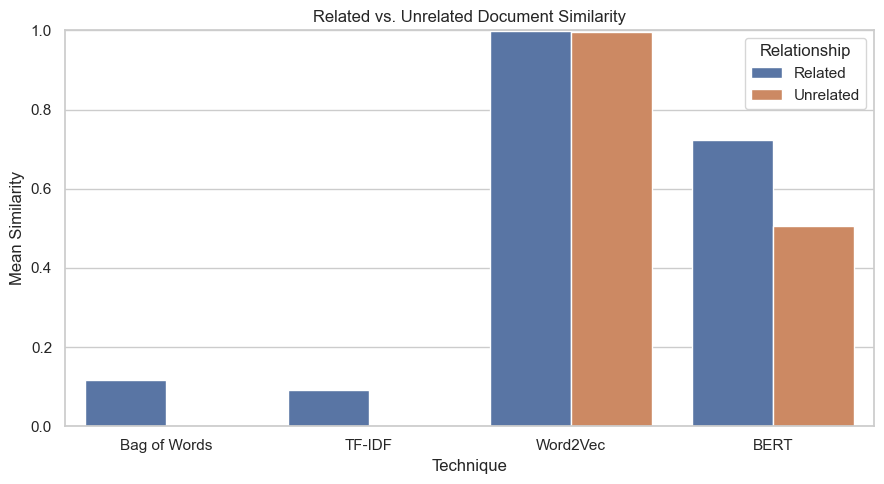

In [9]:
summary = pair_results.groupby(
    ['Technique', 'Relationship']
)['Cosine Similarity'].mean().unstack()
summary['Separation'] = summary['Related'] - summary['Unrelated']
summary = summary.reindex(embedding_sets.keys())
display(summary.round(3))

plot_data = summary[['Related', 'Unrelated']].reset_index().melt(
    id_vars='Technique', var_name='Relationship', value_name='Mean Similarity'
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x='Technique', y='Mean Similarity', hue='Relationship')
plt.title('Related vs. Unrelated Document Similarity')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

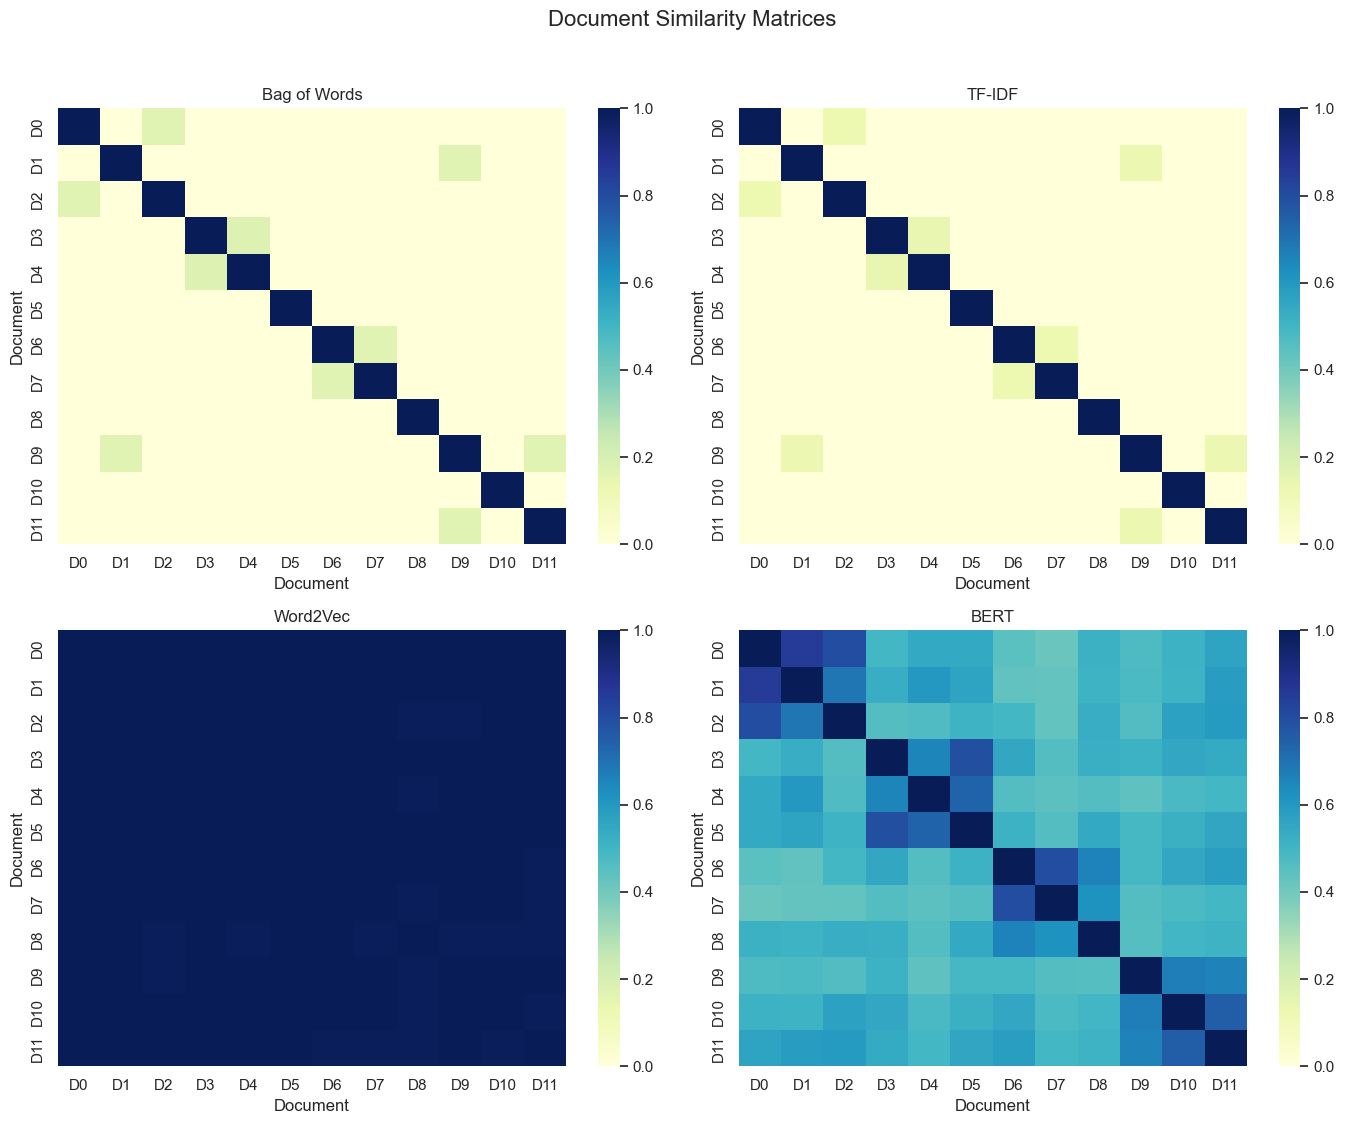

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for axis, (technique, matrix) in zip(axes.flat, similarity_matrices.items()):
    sns.heatmap(matrix, ax=axis, cmap='YlGnBu', vmin=0, vmax=1,
                xticklabels=document_ids, yticklabels=document_ids)
    axis.set_title(technique)
    axis.set_xlabel('Document')
    axis.set_ylabel('Document')
fig.suptitle('Document Similarity Matrices', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Discussion and Conclusion

| Technique | Representation | Main strength | Main limitation |
|---|---|---|---|
| Bag of Words | Sparse word-count vector | Simple and interpretable | Ignores order, context, and meaning |
| TF-IDF | Sparse weighted word vector | Emphasizes informative terms | Depends on exact vocabulary matches |
| Word2Vec Skip-gram | Dense learned word vectors | Learns relationships between words | Needs a large training corpus |
| BERT | Dense contextual vectors | Uses bidirectional context and pretrained knowledge | Requires more memory and computation |

BoW and TF-IDF are useful, fast baselines. In this run, Word2Vec gives almost identical similarities to related and unrelated pairs because twelve sentences are not enough to learn stable semantic relationships; this demonstrates its need for a large training corpus. BERT separates the selected related and unrelated pairs more clearly because it starts with contextual knowledge learned from a very large corpus. The numerical results should still be interpreted together with each method's properties and limitations. For an agentic AI system that must understand varied user instructions, contextual embeddings such as BERT are generally the most useful, while TF-IDF remains a strong lightweight baseline.

### Reference

Patil, R., Boit, S., Gudivada, V., & Nandigam, J. (2023). *A Survey of Text Representation and Embedding Techniques in NLP*. IEEE Access, 11, 36120-36146. https://doi.org/10.1109/ACCESS.2023.3266377